In [18]:
import numpy as np
import matplotlib.pyplot as plt
import copy

import pyccl as ccl

import treecorr

import numpy as np
import matplotlib.pyplot as plt

import sys
import os
import copy

sys.path.append(os.path.abspath("/home/milan/Desktop/thesis/code")) 

In [19]:
from halo_model.power_spectra.matter_power_baryons import MatterPowerBaryons
from halo_model.halos.base.profile.profile import CompositeProfile

from halo_model.config.config import Config

from halo_model.power_spectra.xi_computer import compute_Pk_2d, Pk_2d_to_Cl, Cl_to_xi, compute_xi, covariance_xi

In [20]:
# set config 
cfg = Config()

# decrease resolution for testing
cfg.N_m = 64
cfg.N_M = 32
cfg.N_k = 32

In [21]:
# # Compute power spectrum (at various redshifts):
# Pk_2d = compute_Pk_2d(cfg)

# # compute the Cl from the power spectra:
# Cl = Pk_2d_to_Cl(cfg, Pk_2d)

# # compute xi from the Cls:
# xi = Cl_to_xi(cfg, Cl)

# #plot the power spectra at z = 0.1 and 1
# z_grid = np.linspace(cfg.z_max, cfg.z_min, cfg.N_z) # from high redshift to low redshift so scale factor is monotonically increasing
# a_grid = 1/(1+z_grid)
# k_grid = np.geomspace(cfg.k_min, cfg.k_max, cfg.N_k)

# plt.plot(k_grid, k_grid**3 *Pk_2d(k_grid, 1/(1 + 0.1)), label='z=0.1')
# plt.plot(k_grid, k_grid**3 *Pk_2d(k_grid, 1/(1 + 1)), label='z=1')
# plt.legend()

# plt.xlabel('k [h/Mpc]')
# plt.ylabel(r'$k^3 P_m(k)$')

# plt.title("Power spectrum")
# plt.loglog()
# plt.show()

In [ ]:
# Compute xi standard value
xi = compute_xi(cfg)

# get error bars from flagship
cov = covariance_xi(cfg)
xi_err = np.sqrt(np.diag(cov))

computing power spectrum at redshift 2.0
interpolating Ic and Jc functions...
computing power spectrum at redshift 1.6
interpolating Ic and Jc functions...
computing power spectrum at redshift 1.2
interpolating Ic and Jc functions...
computing power spectrum at redshift 0.8
interpolating Ic and Jc functions...
computing power spectrum at redshift 0.4
interpolating Ic and Jc functions...
computing power spectrum at redshift 0.0
interpolating Ic and Jc functions...


0.5678404104087887


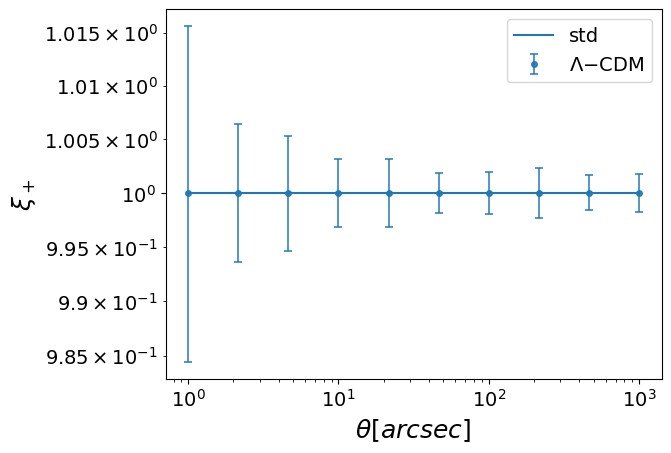

In [24]:
plt.rcParams.update({
    "font.size": 16,          # base font size
    "axes.labelsize": 18,     # x and y labels
    "axes.titlesize": 18,     # title
    "legend.fontsize": 14,    # legend
    "xtick.labelsize": 14,    # x tick labels
    "ytick.labelsize": 14,    # y tick labels
})

# plot the xi_plus vals
theta_deg = np.geomspace(cfg.theta_min/3600, cfg.theta_max/3600, cfg.N_theta)
theta_as = 3600*theta_deg

plt.errorbar(
    theta_as,
    xi/xi,
    yerr = xi_err/xi,
    fmt='o',                 # marker style
    markersize=4,
    color='tab:blue',
    ecolor='tab:blue',       # error bar color
    elinewidth=1.2,          # thickness of error bars
    capsize=3,               # little caps at the end
    capthick=1.2,
    linestyle='none',        # no connecting line
    alpha=0.9,
    label=r'$\Lambda\mathrm{-CDM}$'
)

plt.plot(theta_as, xi/xi, label='std')
plt.ylabel(r'$\xi_+$')
plt.xlabel(r'$\theta [arcsec]$')
plt.legend()
plt.loglog()
plt.show()
